# Bilinear vs Bicubic Interpolation: A Visual and Mathematical Exploration

This notebook demonstrates the differences between bilinear and bicubic interpolation methods used in image upsampling. We explore both the mathematical foundations and practical implementations using PyTorch.

## References
- [Bilinear Interpolation (Wikipedia)](https://en.wikipedia.org/wiki/Bilinear_interpolation)
- [Bicubic Interpolation (Wikipedia)](https://en.wikipedia.org/wiki/Bicubic_interpolation)
- [Nearest-neighbor Interpolation (Wikipedia)](https://en.wikipedia.org/wiki/Nearest-neighbor_interpolation)

## 1. Mathematical Background

### Bilinear Interpolation

Bilinear interpolation performs linear interpolation first in one direction, then in the other direction. Given four corner points $Q_{11}, Q_{12}, Q_{21}, Q_{22}$ at coordinates $(x_1, y_1), (x_1, y_2), (x_2, y_1), (x_2, y_2)$ respectively, the interpolated value at point $(x, y)$ is calculated using weights:

$$w_x = \frac{x - x_1}{x_2 - x_1}$$

$$w_y = \frac{y - y_1}{y_2 - y_1}$$

The interpolated value $f(x, y)$ is computed as:

$$f(x, y) = [1 - w_x \quad w_x] \begin{bmatrix} Q_{11} & Q_{12} \\ Q_{21} & Q_{22} \end{bmatrix} \begin{bmatrix} 1 - w_y \\ w_y \end{bmatrix}$$

Expanding this matrix multiplication:

$$f(x, y) = Q_{11}(1-w_x)(1-w_y) + Q_{21}w_x(1-w_y) + Q_{12}(1-w_x)w_y + Q_{22}w_xw_y$$

### Bicubic Interpolation

Bicubic interpolation uses 16 neighboring points (a 4×4 grid) and fits a cubic polynomial. The general form involves cubic convolution:

$$f(x, y) = \sum_{i=-1}^{2} \sum_{j=-1}^{2} a_{ij} \cdot W(x - i) \cdot W(y - j)$$

where $W(t)$ is the cubic kernel function:

$$W(t) = \begin{cases}
(a+2)|t|^3 - (a+3)|t|^2 + 1 & \text{for } |t| \leq 1 \\
a|t|^3 - 5a|t|^2 + 8a|t| - 4a & \text{for } 1 < |t| < 2 \\
0 & \text{otherwise}
\end{cases}$$

where $a$ is typically -0.5 or -0.75.

In [ ]:
# Import necessary libraries
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from scipy import ndimage

# Set up matplotlib for better display
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## 2. Visual Comparison: Nearest vs Bilinear vs Bicubic

Let's create a simple 2×2 colored grid and upsample it using different interpolation methods to visualize the differences.

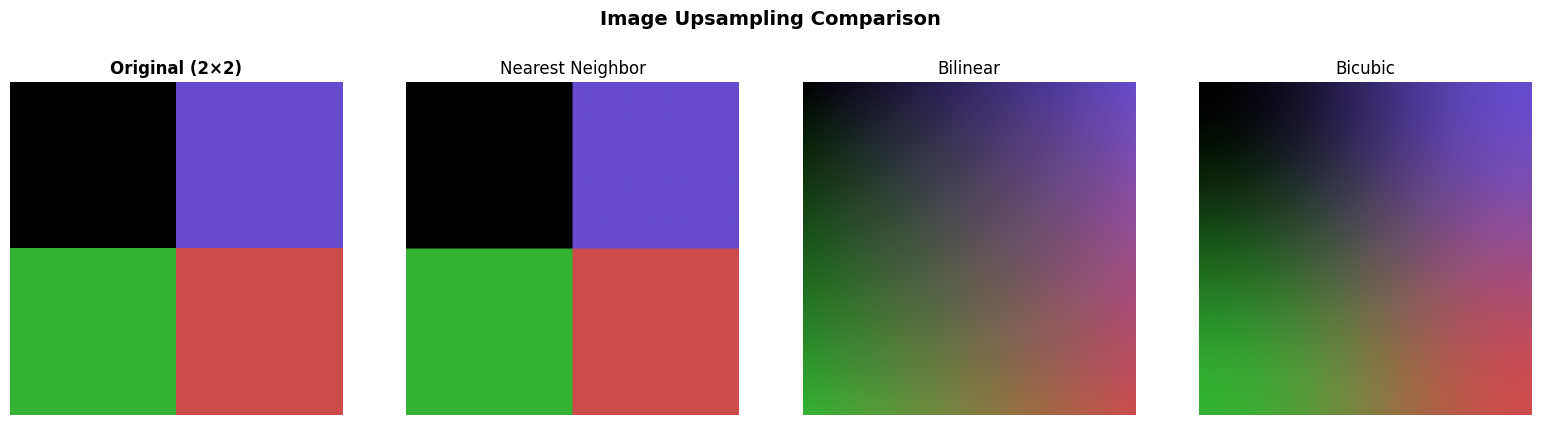

In [ ]:
def create_sample_image():
    """Create a 2x2 colored grid similar to the slide example."""
    # Create a 2x2 image with distinct colors
    img = np.zeros((2, 2, 3), dtype=np.float32)

    # Top-left: black
    img[0, 0] = [0, 0, 0]

    # Top-right: blue/purple
    img[0, 1] = [0.4, 0.3, 0.8]

    # Bottom-left: green
    img[1, 0] = [0.2, 0.7, 0.2]

    # Bottom-right: red/pink
    img[1, 1] = [0.8, 0.3, 0.3]

    return img

def upsample_comparison(img, scale_factor=8):
    """Compare different upsampling methods."""
    h, w = img.shape[:2]
    new_size = (h * scale_factor, w * scale_factor)

    # Nearest neighbor
    nearest = ndimage.zoom(img, (scale_factor, scale_factor, 1), order=0)

    # Bilinear
    bilinear = ndimage.zoom(img, (scale_factor, scale_factor, 1), order=1)

    # Bicubic
    bicubic = ndimage.zoom(img, (scale_factor, scale_factor, 1), order=3)

    return nearest, bilinear, bicubic

# Create and visualize
img = create_sample_image()
nearest, bilinear, bicubic = upsample_comparison(img, scale_factor=64)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original (scaled for visibility)
axes[0].imshow(img, interpolation='nearest')
axes[0].set_title('Original (2×2)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Nearest
axes[1].imshow(nearest)
axes[1].set_title('Nearest Neighbor', fontsize=12)
axes[1].axis('off')

# Bilinear
axes[2].imshow(bilinear)
axes[2].set_title('Bilinear', fontsize=12)
axes[2].axis('off')

# Bicubic
axes[3].imshow(bicubic)
axes[3].set_title('Bicubic', fontsize=12)
axes[3].axis('off')

plt.suptitle('Image Upsampling Comparison', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 3. Bilinear Interpolation: Step-by-Step Example

Let's implement bilinear interpolation from scratch to understand the process. We'll use the example from the slides with specific pixel values.

Bilinear Interpolation Example
Corner values (Q):
[[10. 20.]
 [30. 40.]]

Target point: (0.6, 0.7)

Weights:
  wx = 0.60
  wy = 0.70

Interpolation calculation:
  f(0.6, 0.7) = 10.0×0.4×0.3 + 30.0×0.6×0.3 + 
              20.0×0.4×0.7 + 40.0×0.6×0.7
  f(0.6, 0.7) = 29.0


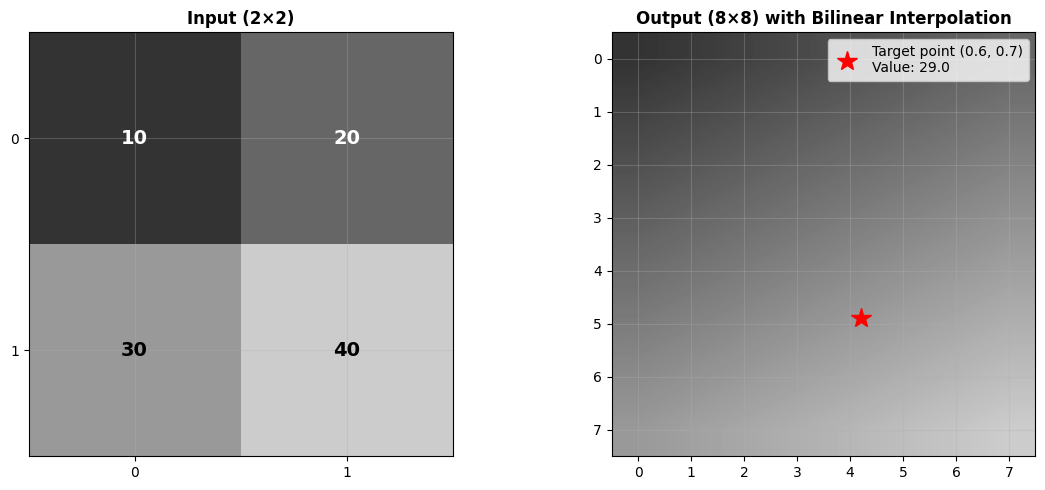

In [ ]:
def bilinear_interpolation_manual(Q, x, y):
    """
    Perform bilinear interpolation manually.

    Q: 2x2 array of corner values [[Q11, Q12], [Q21, Q22]]
    x, y: target coordinates (normalized between 0 and 1)
    """
    # Extract corner values
    Q11, Q12 = Q[0, 0], Q[0, 1]
    Q21, Q22 = Q[1, 0], Q[1, 1]

    # Calculate weights
    wx = x  # Since x1=0, x2=1
    wy = y  # Since y1=0, y2=1

    # Bilinear interpolation formula
    result = (Q11 * (1 - wx) * (1 - wy) +
              Q21 * wx * (1 - wy) +
              Q12 * (1 - wx) * wy +
              Q22 * wx * wy)

    return result, wx, wy

# Example from the slides
Q = np.array([[10, 20],
              [30, 40]], dtype=float)

# Target point at (0.6, 0.7)
x, y = 0.6, 0.7

result, wx, wy = bilinear_interpolation_manual(Q, x, y)

print("Bilinear Interpolation Example")
print("="*40)
print(f"Corner values (Q):\n{Q}")
print(f"\nTarget point: ({x}, {y})")
print(f"\nWeights:")
print(f"  wx = {wx:.2f}")
print(f"  wy = {wy:.2f}")
print(f"\nInterpolation calculation:")
print(f"  f({x}, {y}) = {Q[0,0]}×{1-wx:.1f}×{1-wy:.1f} + {Q[1,0]}×{wx:.1f}×{1-wy:.1f} + ")
print(f"              {Q[0,1]}×{1-wx:.1f}×{wy:.1f} + {Q[1,1]}×{wx:.1f}×{wy:.1f}")
print(f"  f({x}, {y}) = {result:.1f}")

# Visualize the interpolation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Input visualization
ax1.imshow(Q, cmap='gray', vmin=0, vmax=50, interpolation='nearest')
ax1.set_title('Input (2×2)', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{int(Q[i, j])}', ha='center', va='center',
                color='white' if Q[i, j] < 25 else 'black', fontsize=14, fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.grid(True, alpha=0.3)

# Output visualization with interpolated point
Q_upsampled = ndimage.zoom(Q, 4, order=1)
ax2.imshow(Q_upsampled, cmap='gray', vmin=0, vmax=50, interpolation='bilinear')
ax2.set_title('Output (8×8) with Bilinear Interpolation', fontsize=12, fontweight='bold')

# Mark the interpolated point
px, py = x * (Q_upsampled.shape[1] - 1), y * (Q_upsampled.shape[0] - 1)
ax2.plot(px, py, 'r*', markersize=15, label=f'Target point ({x}, {y})\nValue: {result:.1f}')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. PyTorch Implementation

Now let's replicate the PyTorch example from the slides, demonstrating how to use `F.interpolate` with different settings.

In [ ]:
# Create a 1×1×2×2 tensor (batch_size × channels × height × width)
print("PyTorch Bilinear Interpolation Example")
print("="*40)

# Create input tensor matching the slide example
input_tensor = torch.tensor([[[[10, 20],
                               [30, 40]]]], dtype=torch.float32)

print(f"Input tensor shape: {input_tensor.shape}")
print(f"Input tensor:\n{input_tensor.squeeze()}")

# Upscale to 4×4
output_aligned = F.interpolate(input_tensor, size=(4, 4), mode='bilinear', align_corners=True)
output_not_aligned = F.interpolate(input_tensor, size=(4, 4), mode='bilinear', align_corners=False)

print(f"\nOutput shape: {output_aligned.shape}")
print(f"\nWith align_corners=True:\n{output_aligned.squeeze()}")
print(f"\nWith align_corners=False:\n{output_not_aligned.squeeze()}")

PyTorch Bilinear Interpolation Example
Input tensor shape: torch.Size([1, 1, 2, 2])
Input tensor:
tensor([[10., 20.],
        [30., 40.]])

Output shape: torch.Size([1, 1, 4, 4])

With align_corners=True:
tensor([[10.0000, 13.3333, 16.6667, 20.0000],
        [16.6667, 20.0000, 23.3333, 26.6667],
        [23.3333, 26.6667, 30.0000, 33.3333],
        [30.0000, 33.3333, 36.6667, 40.0000]])

With align_corners=False:
tensor([[10.0000, 12.5000, 17.5000, 20.0000],
        [15.0000, 17.5000, 22.5000, 25.0000],
        [25.0000, 27.5000, 32.5000, 35.0000],
        [30.0000, 32.5000, 37.5000, 40.0000]])


/tmp/ipython-input-700242088.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


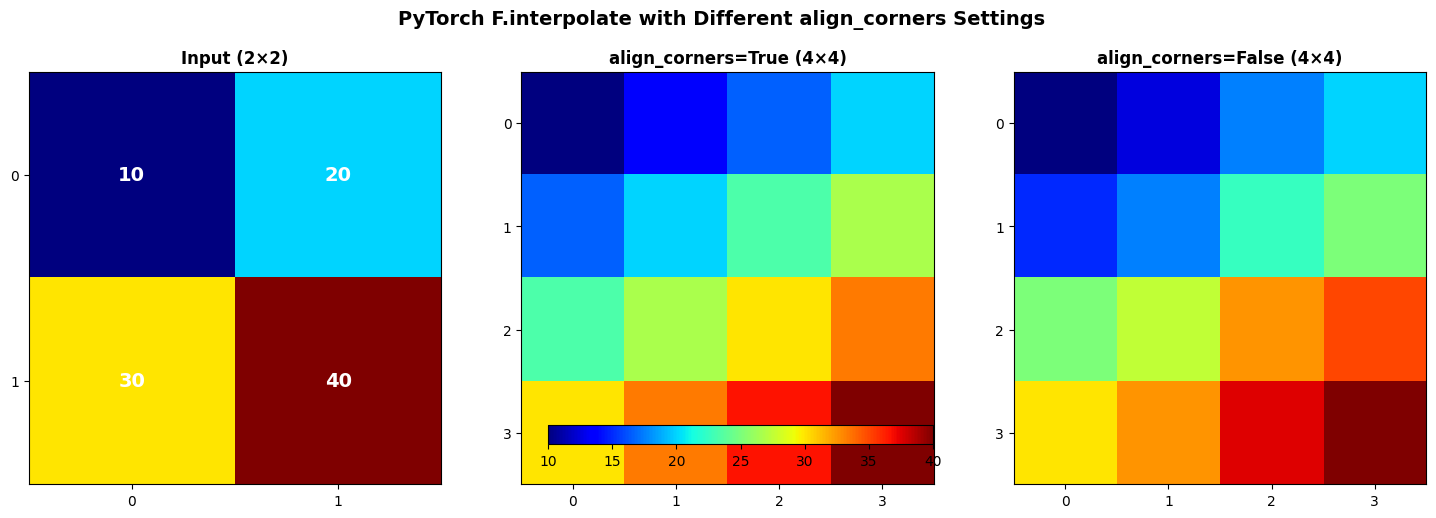

In [ ]:
# Visualize the difference between align_corners settings
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
im0 = axes[0].imshow(input_tensor.squeeze().numpy(), cmap='jet', vmin=10, vmax=40)
axes[0].set_title('Input (2×2)', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{int(input_tensor[0, 0, i, j])}',
                    ha='center', va='center', color='white', fontsize=14, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])

# With align_corners=True
im1 = axes[1].imshow(output_aligned.squeeze().numpy(), cmap='jet', vmin=10, vmax=40)
axes[1].set_title('align_corners=True (4×4)', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))

# With align_corners=False
im2 = axes[2].imshow(output_not_aligned.squeeze().numpy(), cmap='jet', vmin=10, vmax=40)
axes[2].set_title('align_corners=False (4×4)', fontsize=12, fontweight='bold')
axes[2].set_xticks(range(4))
axes[2].set_yticks(range(4))

# Add colorbar
fig.colorbar(im0, ax=axes, orientation='horizontal', pad=0.1, fraction=0.05)

plt.suptitle('PyTorch F.interpolate with Different align_corners Settings',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Comparison of Interpolation Methods on Real Images

Let's compare the three interpolation methods on a more complex pattern to better understand their characteristics.

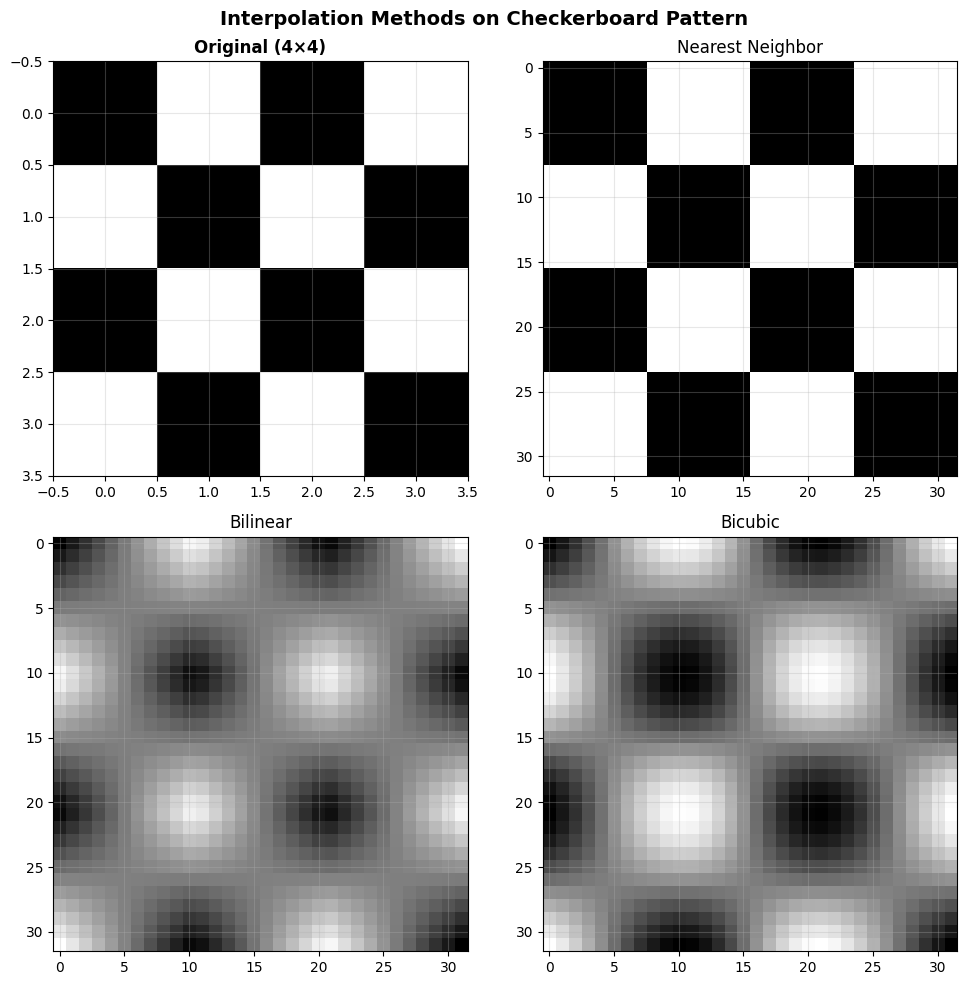

In [ ]:
def create_checkerboard(size=8):
    """Create a checkerboard pattern."""
    board = np.zeros((size, size))
    board[::2, 1::2] = 1
    board[1::2, ::2] = 1
    return board

# Create a small checkerboard
checkerboard = create_checkerboard(4)

# Convert to PyTorch tensor
checker_tensor = torch.tensor(checkerboard, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Upsample using different methods
scale_factor = 8
new_size = (checkerboard.shape[0] * scale_factor, checkerboard.shape[1] * scale_factor)

nearest_torch = F.interpolate(checker_tensor, size=new_size, mode='nearest')
bilinear_torch = F.interpolate(checker_tensor, size=new_size, mode='bilinear', align_corners=True)
bicubic_torch = F.interpolate(checker_tensor, size=new_size, mode='bicubic', align_corners=True)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Original
axes[0, 0].imshow(checkerboard, cmap='gray', interpolation='nearest')
axes[0, 0].set_title('Original (4×4)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Nearest
axes[0, 1].imshow(nearest_torch.squeeze().numpy(), cmap='gray')
axes[0, 1].set_title('Nearest Neighbor', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Bilinear
axes[1, 0].imshow(bilinear_torch.squeeze().numpy(), cmap='gray')
axes[1, 0].set_title('Bilinear', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Bicubic
axes[1, 1].imshow(bicubic_torch.squeeze().numpy(), cmap='gray')
axes[1, 1].set_title('Bicubic', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Interpolation Methods on Checkerboard Pattern', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Edge Profiles Comparison

To better understand the smoothing characteristics of each method, let's examine the edge profiles.

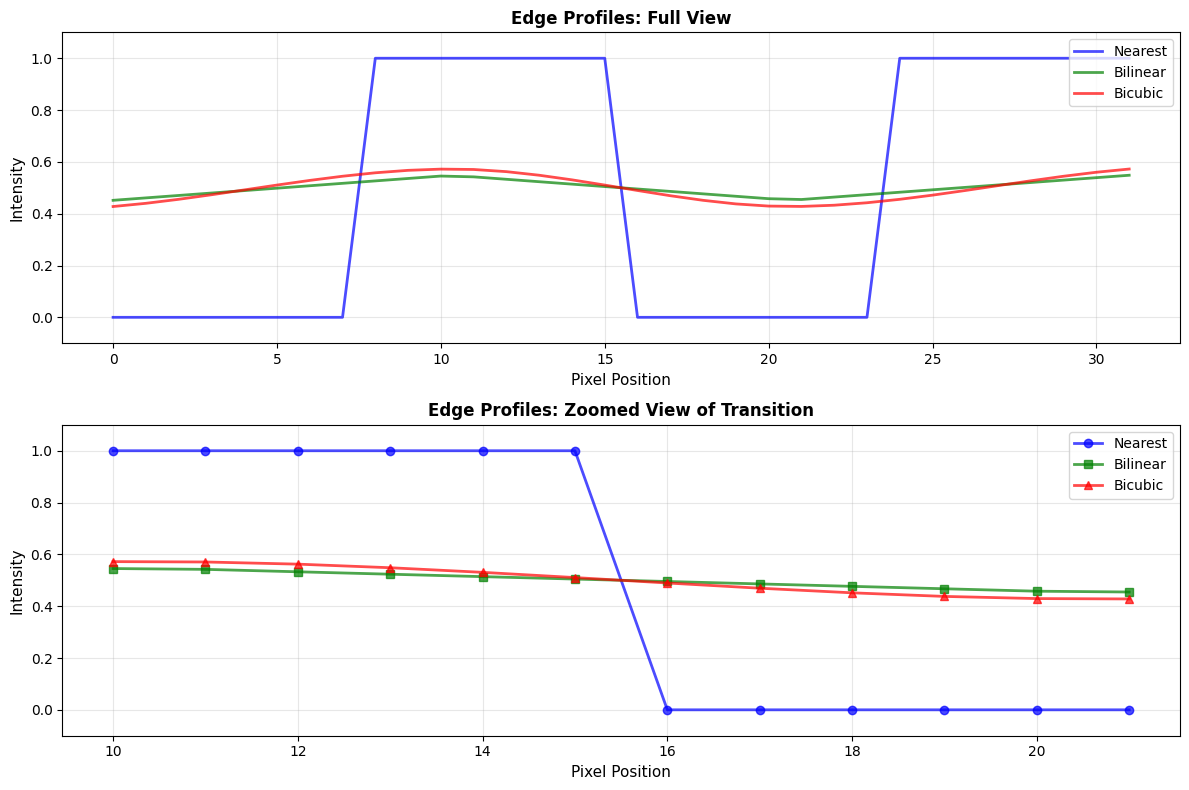

In [ ]:
# Extract a horizontal line through the middle of each upsampled image
middle_row = new_size[0] // 2

nearest_profile = nearest_torch.squeeze().numpy()[middle_row, :]
bilinear_profile = bilinear_torch.squeeze().numpy()[middle_row, :]
bicubic_profile = bicubic_torch.squeeze().numpy()[middle_row, :]

# Plot the profiles
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot all profiles
x_coords = np.arange(len(nearest_profile))
ax1.plot(x_coords, nearest_profile, 'b-', linewidth=2, label='Nearest', alpha=0.7)
ax1.plot(x_coords, bilinear_profile, 'g-', linewidth=2, label='Bilinear', alpha=0.7)
ax1.plot(x_coords, bicubic_profile, 'r-', linewidth=2, label='Bicubic', alpha=0.7)
ax1.set_xlabel('Pixel Position', fontsize=11)
ax1.set_ylabel('Intensity', fontsize=11)
ax1.set_title('Edge Profiles: Full View', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.1, 1.1)

# Zoomed view of a single edge transition
zoom_start, zoom_end = 10, 22
ax2.plot(x_coords[zoom_start:zoom_end], nearest_profile[zoom_start:zoom_end],
         'b-', linewidth=2, marker='o', label='Nearest', alpha=0.7)
ax2.plot(x_coords[zoom_start:zoom_end], bilinear_profile[zoom_start:zoom_end],
         'g-', linewidth=2, marker='s', label='Bilinear', alpha=0.7)
ax2.plot(x_coords[zoom_start:zoom_end], bicubic_profile[zoom_start:zoom_end],
         'r-', linewidth=2, marker='^', label='Bicubic', alpha=0.7)
ax2.set_xlabel('Pixel Position', fontsize=11)
ax2.set_ylabel('Intensity', fontsize=11)
ax2.set_title('Edge Profiles: Zoomed View of Transition', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

**1. What is being plotted?**

*   **X-axis (Pixel Position):** This represents the horizontal position of each pixel along a single, middle row of the upscaled checkerboard image.
*   **Y-axis (Intensity):** This shows the brightness value of each pixel at that position, ranging from 0 (black) to 1 (white).

**2. Why use a checkerboard pattern?**

The checkerboard is an ideal pattern for this analysis because it is composed entirely of sharp edges where black and white squares meet. This abrupt transition from black (intensity 0) to white (intensity 1) provides a clear and challenging test for the interpolation methods.

**3. What do the edge profiles reveal about each interpolation method?**

By plotting the intensity values along a line that crosses these black-to-white transitions, the notebook graphically demonstrates the core characteristics of each interpolation method:

*   **Nearest Neighbor:** The profile for this method looks like a series of sharp, rectangular steps. The intensity abruptly jumps from 0 to 1 without any intermediate values. This visually confirms the "blocky" artifacts and that no new pixel values are created.

*   **Bilinear Interpolation:** The profile shows a straight, diagonal line at the transition between black and white. This linear slope illustrates that bilinear interpolation creates a smooth, linear gradient between the original pixel values, which can result in some blurring of the sharp edge.

*   **Bicubic Interpolation:** The profile for this method is a smoother, curved line (an "S" shape) at the edge. A key characteristic highlighted in the zoomed-in plot is "overshoot," where the intensity value temporarily goes slightly below 0 or above 1 at the edge. This phenomenon, also known as ringing artifacts, is a trade-off for achieving a smoother and often more perceptually pleasing transition in natural images.

This is a side-by-side comparison of how each interpolation algorithm reconstructs a sharp edge, making it easy to understand their respective smoothing and artifact-producing behaviors.

## 7. Key Observations and Summary

### Characteristics of Each Method:

**Nearest Neighbor:**
- Preserves sharp edges
- Creates blocky artifacts
- Fastest computation
- No new pixel values introduced

**Bilinear:**
- Smooth transitions between pixels
- Linear gradient between neighboring values
- Moderate computational cost
- Can blur sharp features

**Bicubic:**
- Smoothest transitions
- Can overshoot at edges (ringing artifacts)
- Highest computational cost
- Best for natural images with gradual changes

### Mathematical Complexity:

| Method | Neighboring Pixels Used | Polynomial Degree | Smoothness |
|--------|-------------------------|-------------------|------------|
| Nearest | 1 | 0 (constant) | $C^{-1}$ (discontinuous) |
| Bilinear | 4 | 1 (linear) | $C^0$ (continuous) |
| Bicubic | 16 | 3 (cubic) | $C^1$ (smooth) |

## 8. Practical Application: Custom Interpolation Function

Let's implement a function that allows you to experiment with different interpolation methods and parameters.

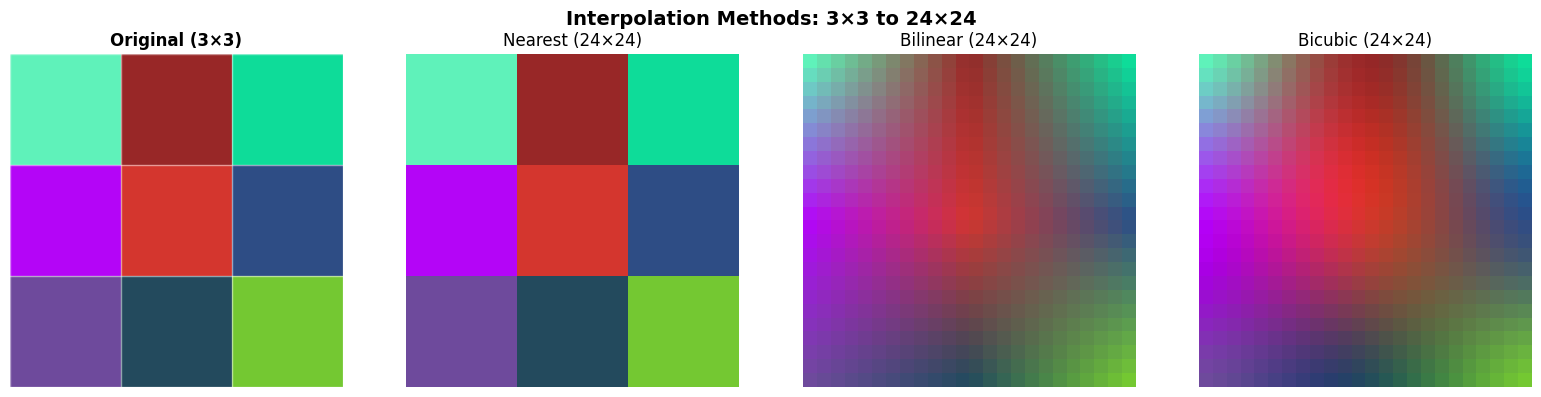


Interpolation Complete!
Notice how:
  • Nearest neighbor creates sharp, blocky edges
  • Bilinear creates smooth gradients between pixels
  • Bicubic creates the smoothest transitions with slight overshoot


In [ ]:
def interactive_interpolation_demo(input_size=3, output_size=12):
    """
    Create an interactive demonstration of interpolation methods.
    """
    # Create a random input image
    np.random.seed(42)
    input_img = np.random.rand(input_size, input_size, 3)

    # Convert to tensor
    input_tensor = torch.tensor(input_img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

    # Apply different interpolation methods
    methods = {
        'Nearest': F.interpolate(input_tensor, size=(output_size, output_size), mode='nearest'),
        'Bilinear': F.interpolate(input_tensor, size=(output_size, output_size), mode='bilinear', align_corners=True),
        'Bicubic': F.interpolate(input_tensor, size=(output_size, output_size), mode='bicubic', align_corners=True)
    }

    # Visualize
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Original
    axes[0].imshow(input_img)
    axes[0].set_title(f'Original ({input_size}×{input_size})', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Add grid to original
    for i in range(input_size + 1):
        axes[0].axhline(i - 0.5, color='white', linewidth=1, alpha=0.5)
        axes[0].axvline(i - 0.5, color='white', linewidth=1, alpha=0.5)

    # Interpolated images
    for idx, (name, result) in enumerate(methods.items(), 1):
        img_result = result.squeeze(0).permute(1, 2, 0).numpy()
        axes[idx].imshow(img_result)
        axes[idx].set_title(f'{name} ({output_size}×{output_size})', fontsize=12)
        axes[idx].axis('off')

    plt.suptitle(f'Interpolation Methods: {input_size}×{input_size} to {output_size}×{output_size}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return input_img, methods

# Run the demonstration
input_img, results = interactive_interpolation_demo(input_size=3, output_size=24)

print("\nInterpolation Complete!")
print("Notice how:")
print("  • Nearest neighbor creates sharp, blocky edges")
print("  • Bilinear creates smooth gradients between pixels")
print("  • Bicubic creates the smoothest transitions with slight overshoot")

## Conclusion

This notebook demonstrated the mathematical foundations and practical differences between nearest neighbor, bilinear, and bicubic interpolation methods. Key takeaways:

1. **Nearest neighbor** is fast but produces blocky results
2. **Bilinear interpolation** provides a good balance between quality and speed
3. **Bicubic interpolation** offers the highest quality but at increased computational cost

The choice of interpolation method depends on your specific application:
- Use **nearest** for pixel art or when preserving exact values is critical
- Use **bilinear** for general purpose image resizing with good performance
- Use **bicubic** for high-quality image processing where smoothness is important

### Further Reading
- [Digital Image Processing](https://en.wikipedia.org/wiki/Digital_image_processing)
- [Image Scaling Algorithms](https://en.wikipedia.org/wiki/Image_scaling)
- [PyTorch Interpolation Documentation](https://pytorch.org/docs/stable/nn.functional.html#torch.nn.functional.interpolate)